In [ ]:
import sys
!{sys.executable} -m pip install pandas

In [ ]:
import sys
!{sys.executable} -m pip install seaborn

In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn==1.4.0

In [ ]:
import sys
!{sys.executable} -m pip install tensorflow==2.12.1

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("TensorFlow is working!")

In [2]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

# Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers.core import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils.np_utils import to_categorical
from keras.wrappers.scikit_learn import KerasClassifier


In [2]:
import sys
print(sys.executable)

E:\anaconda3\envs\deeplearning\python.exe


In [3]:
# Digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

In [4]:
X_train_digit[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [5]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

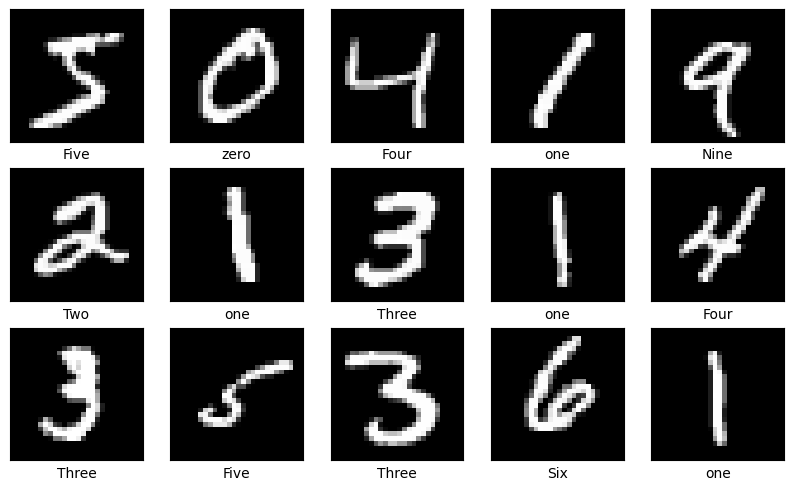

In [6]:
# Number of numbers in the dataset in order
col_names = ['zero','one','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [7]:
# Dataset in 3D dimension
X_train_digit.shape

(60000, 28, 28)

In [8]:
# convert 3D to 2D dimension
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

In [9]:
X_train_digit.shape

(60000, 784)

In [10]:
y_test_digit.shape

(10000,)

In [11]:
#Encoding Digit MNIST models
y_train_digit = to_categorical(y_train_digit, num_classes=10)
y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [12]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [14]:
# Creating base neural networks # Procedure creation
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(10, activation='sigmoid'),
])
    

In [15]:
#param_number = output_channel_number * (input_channel_number + 1)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               200960    
                                                                 
 dense_5 (Dense)             (None, 64)                16448     
                                                                 
 dense_6 (Dense)             (None, 64)                4160      
                                                                 
 dense_7 (Dense)             (None, 10)                650       
                                                                 
Total params: 222,218
Trainable params: 222,218
Non-trainable params: 0
_________________________________________________________________


In [20]:
# Compiling the model
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

              

In [21]:
# Train model
history=model.fit(X_train_digit, y_train_digit, batch_size=100, epochs=10,validation_data=(X_test_digit, y_test_digit))

Epoch 1/10
600/600 [==============================] - 5s 7ms/step - loss: 1.3542 - accuracy: 0.8628 - val_loss: 0.3763 - val_accuracy: 0.9185
Epoch 2/10
600/600 [==============================] - 4s 6ms/step - loss: 0.2476 - accuracy: 0.9374 - val_loss: 0.2488 - val_accuracy: 0.9399
Epoch 3/10
600/600 [==============================] - 4s 6ms/step - loss: 0.1636 - accuracy: 0.9563 - val_loss: 0.2186 - val_accuracy: 0.9456
Epoch 4/10
600/600 [==============================] - 4s 7ms/step - loss: 0.1259 - accuracy: 0.9651 - val_loss: 0.2303 - val_accuracy: 0.9467
Epoch 5/10
600/600 [==============================] - 4s 6ms/step - loss: 0.1126 - accuracy: 0.9680 - val_loss: 0.1794 - val_accuracy: 0.9577
Epoch 6/10
600/600 [==============================] - 4s 6ms/step - loss: 0.1000 - accuracy: 0.9714 - val_loss: 0.1893 - val_accuracy: 0.9559
Epoch 7/10
600/600 [==============================] - 4s 7ms/step - loss: 0.0904 - accuracy: 0.9746 - val_loss: 0.1629 - val_accuracy: 0.9642
Epoch 

In [22]:
# Predicting the lables-DIGIT
y_predict = model.predict(X_test_digit)

313/313 [==============================] - 1s 2ms/step


In [23]:
y_predict[0]

array([9.6841139e-01, 9.9895209e-01, 9.8266518e-01, 9.9999946e-01,
       9.9999452e-01, 2.4995083e-01, 1.8306369e-11, 1.0000000e+00,
       3.9718084e-02, 9.9999982e-01], dtype=float32)

In [24]:
# Here we get the index of maximum value in the encoded vector
y_predicts=np.argmax(y_predict, axis=1)

In [26]:
# test set Prediction
y_predicts

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [27]:
y_test_digit_eval=np.argmax(y_test_digit, axis=1)

In [28]:
# Actual test prediction
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

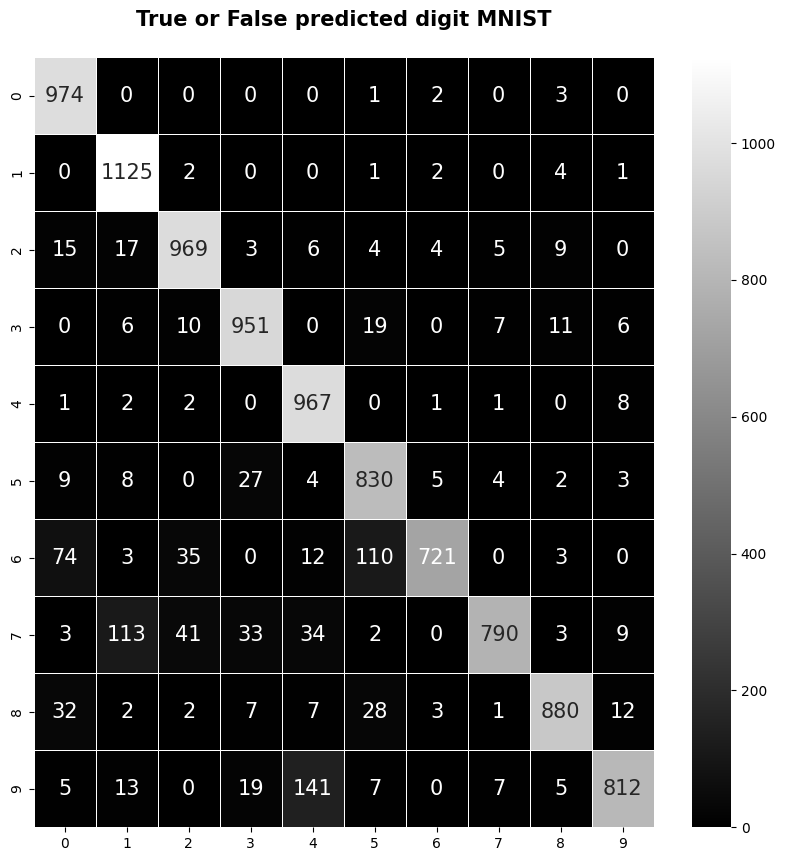

In [30]:
# Confusion matrix for Digit Mnist
con_mat=confusion_matrix(y_test_digit_eval,y_predicts)
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size': 15},linewidths=0.5,fmt="d",cmap="gray")
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       980
           1       0.87      0.99      0.93      1135
           2       0.91      0.94      0.93      1032
           3       0.91      0.94      0.93      1010
           4       0.83      0.98      0.90       982
           5       0.83      0.93      0.88       892
           6       0.98      0.75      0.85       958
           7       0.97      0.77      0.86      1028
           8       0.96      0.90      0.93       974
           9       0.95      0.80      0.87      1009

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



In [32]:
print(history.history.keys())


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


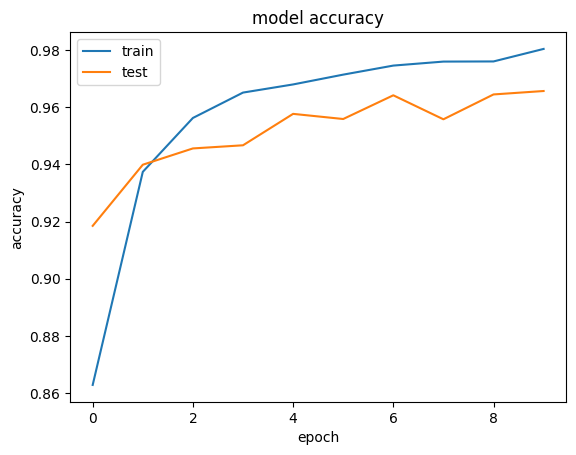

In [41]:
# Summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


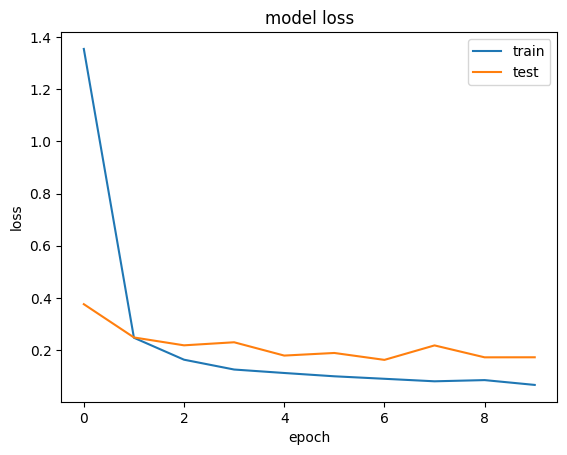

In [42]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [43]:
#tf.expand_dims(X_test_digit[0])
y_predict_single = model.predict(X_test_digit[[2]])
y_predicts_single=np.argmax(y_predict_single, axis=1) #here we get the index of maximum value in the encoded vector
y_test_digit_eval=np.argmax(y_test_digit, axis=1)

1/1 [==============================] - 0s 58ms/step


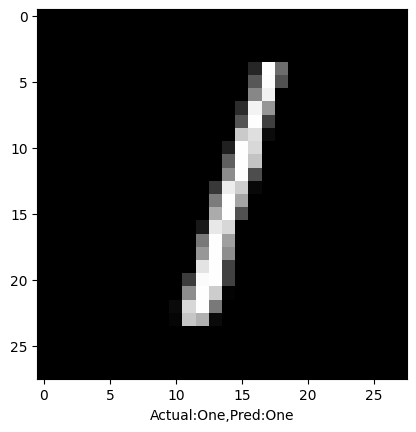

In [44]:
# Names of Numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
#plt.figure(figsize=(10,10))
plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[2])],col_names[y_predicts_single[0]]))
plt.show()
